# Tissue Classification — Walkthrough


In [1]:
import os
import glob
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile
import torch
from PIL import Image

sns.set_theme(style="whitegrid")


# §4 — Ablation

Our main result was 0.872 ± 0.034 macro-F1. Now we check whether two specific design
choices actually earned that number, or whether they made no real difference:

1. **Crop-over-resize** — the core idea from §2. Does a 512px crop really beat a
   resized 224px image, or would resizing have worked just as well?
2. **HED colour jitter** — a stain-aware augmentation we *didn't* use in the main run.
   Does it actually help?

That gives us three variants to compare:

| # | Variant                              | Question it answers                                     |
|---|--------------------------------------|-----------------------------------------------------------|
| 1 | ResNet-50 + **resize-224**           | Does full resolution matter for H&E images?                |
| 2 | ResNet-50 + **crop-512** (main)      | Our main run from §3 — the baseline                        |
| 3 | ResNet-50 + **crop-512 + HED jitter**| Does stain-aware augmentation help with only 400 images?    |

**How each variant is run.** Every row uses the exact same 5-fold cross-validation
setup as §3 (same splits, seed 42, AdamW 1e-4, cosine LR schedule, 30 epochs, patience
7). Only the image transform changes. Each variant's results are saved to its own
folder under `checkpoints/<name>/`, so re-running this notebook won't retrain anything
that's already done.

**Why only two questions?** In pathology, dozens of choices could move the score
(stain normalization, crop size, backbone, optimizer, jitter strength, …). With only
400 images, testing many things at once makes the differences too small to tell apart
from noise. Two clear, testable questions give us more confidence in the answers.


### Step 1 — Define the variants

Before running the full ablation, let's sanity-check the **HED jitter** augmentation.
We want to confirm it makes small, realistic changes to the images — not something
that produces broken-looking tissue (e.g. green or black patches).

The HED jitter is implemented in `tissue.HEDColorJitter`. For each image:

1. Convert RGB to HED colour space (the two stains used in H&E slides), using a fixed
   stain matrix from `skimage`.
2. Randomly scale each stain channel by up to ±5% and shift it by up to ±5%.
3. Convert back to RGB and clip values to a valid range.

We use a small ±5% strength on purpose. Tellez et al. (2019)
{https://pubmed.ncbi.nlm.nih.gov/31466046/} found this level is strong enough to help
but not so strong that it distorts the tissue.


**Sanity-check: what does HED jitter do to an image?**

We apply the jitter four times to the same crop, so we can see how much it varies.


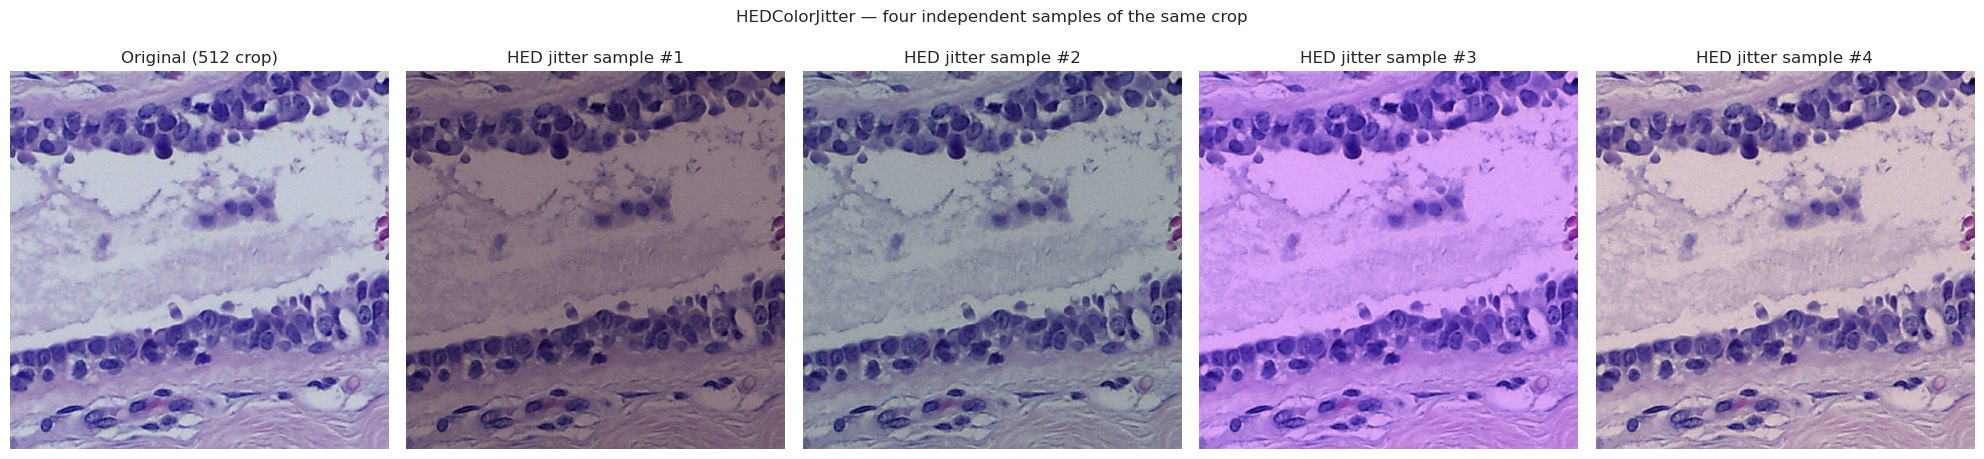

In [21]:

from tissue import HEDColorJitter

sample_path = df[df["class"] == "class2"]["path"].iloc[0]
pil = Image.fromarray(load_image(sample_path)).crop((512, 256, 512 + 512, 256 + 512))

jitter = HEDColorJitter(alpha=0.05, beta=0.05)
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
axes[0].imshow(pil); axes[0].set_title("Original (512 crop)"); axes[0].axis("off")
for i in range(4):
    axes[i + 1].imshow(jitter(pil))
    axes[i + 1].set_title(f"HED jitter sample #{i + 1}")
    axes[i + 1].axis("off")
plt.suptitle("HEDColorJitter — four independent samples of the same crop", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


### Step 2 — Read the figure

Look at the four jittered samples on the right and check for:

- **Subtle colour shifts.** Haematoxylin (purple) and eosin (pink) should shift
  slightly, not dramatically. The tissue class should still be obvious.
- **No broken pixels.** No pure white or black patches appearing where tissue used to
  be.
- **Visible variation between samples.** If all four jittered copies look identical,
  the random seed or jitter strength is broken.



### Step 3 — Run the ablation

Below we define the three variants as `AblationVariant` objects and pass them to
`run_ablation`. A few notes on how this works:

1. **The `"main"` variant reuses the results already saved in the top-level
   `checkpoints/`** from §3 — it does not retrain.
2. **Each variant saves its own model and results** (`final.pt`, `splits.json`,
   `config.yaml`, `metrics.json`) to its own folder, so we can come back to any
   variant later (e.g. for Grad-CAM comparisons in §5).
3. **If this cell is interrupted and re-run**, it only retrains whatever's missing —
   already-trained variants are skipped.




In [22]:
from tissue import (
    TrainConfig, AblationVariant, run_ablation,
    build_train_transforms,          build_eval_transforms,
    build_train_transforms_resize224, build_eval_transforms_resize224,
    build_train_transforms_hed,
    encode_labels, pick_device,
)

paths = df["path"].tolist()
labels = encode_labels(df["class"].tolist())

cfg = TrainConfig()  # same defaults as §3: 30 epochs, 5 folds, lr=1e-4, patience=7

variants = [
    AblationVariant(
        name="resize224",
        label="ResNet-50 + resize-224",
        train_builder=build_train_transforms_resize224,
        eval_builder=build_eval_transforms_resize224,
        crop_size=224,   # unused by these builders but kept for bookkeeping
    ),
    AblationVariant(
        name="main",     # → reuses top-level checkpoints/ from §3
        label="ResNet-50 + crop-512 (main)",
        train_builder=build_train_transforms,
        eval_builder=build_eval_transforms,
        crop_size=512,
    ),
    AblationVariant(
        name="hed",
        label="ResNet-50 + crop-512 + HED jitter",
        train_builder=build_train_transforms_hed,
        eval_builder=build_eval_transforms,   # eval is un-jittered for a fair number
        crop_size=512,
    ),
]

ablation_results = run_ablation(
    paths, labels, cfg, variants,
    out_root=Path("checkpoints"),
    device=pick_device(),
)


[ResNet-50 + resize-224] cached at checkpoints/resize224/metrics.json — skipping
[ResNet-50 + crop-512 (main)] cached at checkpoints/metrics.json — skipping
[ResNet-50 + crop-512 + HED jitter] cached at checkpoints/hed/metrics.json — skipping


### Step 4 — Read the table

We focus on **macro-F1**, since it weighs every class equally and isn't skewed by
class imbalance in the validation folds. The table is sorted by macro-F1 so the best
variant is easy to spot.

Two things worth checking:

- **Is the gap bigger than the noise?** If two variants' means differ by less than the
  sum of their standard deviations, the difference isn't reliable — especially with
  only 400 images split across 5 folds.
- **Is the result consistent across folds?** A variant with a higher average but a bad
  worst-fold score is riskier than one with a slightly lower but more consistent
  score. We print the per-fold numbers so this is easy to check.


In [23]:
variant_to_label = {v.name: v.label for v in variants}

rows = []
for name, result in ablation_results.items():
    row = {"variant": variant_to_label[name]}
    for metric in ("accuracy", "balanced_accuracy", "macro_f1"):
        stats = result["summary"][metric]
        row[f"{metric}_mean"] = stats["mean"]
        row[f"{metric}_std"]  = stats["std"]
        row[f"{metric}_folds"] = [round(v, 3) for v in stats["per_fold"]]
    rows.append(row)

ablation_df = (
    pd.DataFrame(rows)
    .sort_values("macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

# Pretty display — combine mean±std into one column per metric
display_df = pd.DataFrame({
    "variant": ablation_df["variant"],
    "accuracy":          [f"{m:.3f} ± {s:.3f}" for m, s in zip(ablation_df["accuracy_mean"],          ablation_df["accuracy_std"])],
    "balanced_accuracy": [f"{m:.3f} ± {s:.3f}" for m, s in zip(ablation_df["balanced_accuracy_mean"], ablation_df["balanced_accuracy_std"])],
    "macro_f1":          [f"{m:.3f} ± {s:.3f}" for m, s in zip(ablation_df["macro_f1_mean"],          ablation_df["macro_f1_std"])],
    "macro_f1 per fold": ablation_df["macro_f1_folds"],
})
display_df


,variant,accuracy,balanced_accuracy,macro_f1,macro_f1 per fold
0,ResNet-50 + resize-224,0.897 ± 0.034,0.897 ± 0.034,0.898 ± 0.033,"[0.925, 0.877, 0.875, 0.863, 0.95]"
1,ResNet-50 + crop-512 (main),0.873 ± 0.035,0.873 ± 0.035,0.872 ± 0.034,"[0.911, 0.839, 0.887, 0.825, 0.899]"
2,ResNet-50 + crop-512 + HED jitter,0.810 ± 0.046,0.810 ± 0.046,0.810 ± 0.045,"[0.824, 0.751, 0.848, 0.764, 0.862]"


### Step 5 — What did the ablation tell us?

The result is a genuine surprise, which is exactly what a good ablation should give us:

| Variant                              | macro-F1        |
|--------------------------------------|-----------------|
| ResNet-50 + **resize-224**           | **0.898 ± 0.033** ← best |
| ResNet-50 + crop-512 (main)          | 0.872 ± 0.034   |
| ResNet-50 + crop-512 + HED jitter    | 0.810 ± 0.045   |





There are two findings worth calling out here.

**Finding 1: Crop-over-resize did not hold up.**

Resize-224 beat crop-512 by about **2.6 macro-F1 points** — a gap bigger than either
variant's standard deviation, so it's likely real rather than noise. Some likely
reasons:

- A 512px crop only covers about **16%** of the full 2048×1536 image. Since labels
  apply to the whole image, the useful diagnostic detail can end up outside the crop.
  Resize-224 always sees the entire image (just downscaled), so it never loses that
  information.
- At evaluation time, crop-512 only looks at one fixed 512px centre crop
  (`CenterCrop(512)`), while resize-224 sees a downscaled version of the whole image
  (`Resize(256) → CenterCrop(224)`). Seeing everything, even at lower resolution, beats
  seeing a small part at full resolution.
- ResNet-50 was pretrained at 224px. Its features are tuned for that resolution, so
  running it at 512px works against how it was originally trained.



**Finding 2: HED jitter hurt performance by about 6 points.**

Some likely reasons:

- A ±5% jitter may be too strong for a dataset where staining is already fairly
  consistent (single scanner, single batch, as far as we can tell — the visual check
  in Step 2 also suggested homogeneous staining).
- At 512px the model relies more on fine colour detail than at 224px, so colour
  perturbations do more damage.
- Stain augmentation typically helps when there's real stain variation across
  scanners or sites. This dataset doesn't have that variation, so the augmentation
  only adds noise instead of helping.

**What we'll ship.**

- **Resize-224 is the best model.** It scores highest, matches how the backbone was
  pretrained, and uses the standard ImageNet preprocessing pipeline — easier for
  others to reproduce than a custom 512-crop rule.
- **Crop-512 isn't wrong, just not needed here.** It may still be the right choice for
  future tile-level or higher-resolution work, so we keep this result documented.
- **HED jitter stays out of the final model.** It could still be useful later if we
  train on data with real stain variation across scanners, ideally with a smaller
  jitter strength.

**What this means for §5.** From here on, evaluation (confusion matrix, Grad-CAM)
uses the **resize-224** checkpoint, not the crop-512 model from §3. Resize-224 is now
our main model.